# Proyecto Final de Procesamiento Digital de Señales
### Filtrado digital de voz en presencia de ruido aditivo

**Facultad de Ingeniería, UNAM**

*   Pozos Hernández Angel
*   Silverio Martínez Andrés

Este cuaderno implementa el flujo completo del proyecto:

1. Carga la señal de voz y los archivos de ruido.
2. Genera dos casos de señal ruidosa (Caso A moderado, Caso B severo).
3. Analiza las señales en tiempo y frecuencia.
4. Diseña y aplica un **filtro FIR pasa-bajas** para atenuar el ruido blanco.
5. Calcula métricas de error (ECM y SNR) antes y después del filtrado.
6. Diseña **a mano** un **filtro IIR notch** para eliminar un tono de 60 Hz.


---
## 1. Configuración inicial

Importamos las librerías necesarias y definimos los parámetros globales del proyecto.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal as sig
from IPython.display import Audio, display

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("Librerías importadas correctamente.")


Librerías importadas correctamente.


### Parámetros globales del proyecto

Estos son los valores que controlan todo el procesamiento.


In [ ]:
# Configuración de señales y ruido
FS = 16000  # Hz
SNR_CASO_A_DB = 10.0
SNR_CASO_B_DB = 0.0

# Filtro FIR pasa-bajas
FC_PB = 3400.0  # Hz
ANCHO_TRANSICION = 500  # Hz
VENTANA_FIR = "hamming"

# Filtro IIR Notch
F_NOTCH = 60.0  # Hz
Q_NOTCH = 30.0

print(f"Frecuencia de muestreo:      {FS} Hz")
print(f"Frecuencia de Nyquist:       {FS/2} Hz")
print(f"Caso A: SNR = {SNR_CASO_A_DB} dB")
print(f"Caso B: SNR = {SNR_CASO_B_DB} dB")
print(f"Filtro FIR: fc = {FC_PB} Hz, ventana = {VENTANA_FIR}")
print(f"Filtro notch: f0 = {F_NOTCH} Hz, Q = {Q_NOTCH}")

Frecuencia de muestreo:      16000 Hz
Frecuencia de Nyquist:       8000.0 Hz
Caso A: SNR = 10.0 dB
Caso B: SNR = 0.0 dB
Filtro FIR: fc = 3400.0 Hz, ventana = hamming
Filtro notch: f0 = 60.0 Hz, Q = 30.0


---
## 2. Carga de los archivos de audio

- `voz_original.wav` ( grabación de voz)
- `ruido_blanco.wav` (ruido blanco gaussiano)
- `ruido.wav` (tono de 60 Hz)


In [ ]:
try:
    from google.colab import files
    EN_COLAB = True
    print("Estamos en Google Colab.")
    print("Sube los 3 archivos: voz_original.wav, ruido_blanco.wav, ruido.wav")
    subidos = files.upload()
    print("\nArchivos subidos:")
    for nombre in subidos:
        print(f"  - {nombre}  ({len(subidos[nombre])} bytes)")
except ImportError:
    EN_COLAB = False
    print("No estamos en Colab. Se asume que los archivos están en el directorio actual.")


Estamos en Google Colab.
Sube los 3 archivos: voz_original.wav, ruido_blanco.wav, ruido.wav


Saving ruido.wav to ruido.wav
Saving ruido_blanco.wav to ruido_blanco.wav
Saving voz_original.wav to voz_original.wav

Archivos subidos:
  - ruido.wav  (320058 bytes)
  - ruido_blanco.wav  (320058 bytes)
  - voz_original.wav  (1334550 bytes)


### Funciones auxiliares para cargar audio

Definimos dos funciones: una para cargar la voz  (resamplea de forma automática si está en otra frecuencia el audio) y otra para cargar los archivos de ruido.


In [ ]:
def cargar_voz(ruta, fs_objetivo=FS):
    """Carga una señal de voz desde un .wav y la resamplea si es necesario."""
    fs, x = wavfile.read(ruta)
    dtype_original = x.dtype
    x = x.astype(float)
    if x.ndim > 1:                          # Estéreo -> mono
        x = x.mean(axis=1)
    if np.issubdtype(dtype_original, np.integer):
        x = x / np.max(np.abs(x) + 1e-12)   # Normaliza a [-1, 1]

    print(f"[voz] cargada: fs={fs} Hz, N={len(x)}")

    if fs != fs_objetivo:
        from math import gcd
        g = gcd(fs_objetivo, fs)
        up, down = fs_objetivo // g, fs // g
        x = sig.resample_poly(x, up, down)
        fs = fs_objetivo
        print(f"[voz] resampleada a fs={fs} Hz, N={len(x)}")

    return x.astype(np.float32), fs


def cargar_ruido(ruta, N_objetivo, fs_objetivo=FS):
    """Carga un archivo de ruido, lo resamplea y ajusta su longitud."""
    fs, r = wavfile.read(ruta)
    dtype_original = r.dtype
    r = r.astype(float)
    if r.ndim > 1:
        r = r.mean(axis=1)
    if np.issubdtype(dtype_original, np.integer):
        r = r / np.max(np.abs(r) + 1e-12)

    if fs != fs_objetivo:
        from math import gcd
        g = gcd(fs_objetivo, fs)
        up, down = fs_objetivo // g, fs // g
        r = sig.resample_poly(r, up, down)
        fs = fs_objetivo

    # Ajusta a la longitud objetivo
    if len(r) >= N_objetivo:
        r = r[:N_objetivo]
    else:
        reps = int(np.ceil(N_objetivo / len(r)))
        r = np.tile(r, reps)[:N_objetivo]

    return r.astype(np.float32), fs


print("Funciones de carga definidas.")


Funciones de carga definidas.


In [ ]:
# Carga los archivos
x, fs = cargar_voz("voz_original.wav")
N = len(x)
duracion = N / fs

print(f"\nResumen de la voz:")
print(f"  Muestras totales: N = {N}")
print(f"  Duración:         T = {duracion:.2f} s")
print(f"  Frecuencia muestreo: fs = {fs} Hz")

# Carga los dos archivos de ruido
r_blanco, _ = cargar_ruido("ruido_blanco.wav", N_objetivo=N)
r_tono,   _ = cargar_ruido("ruido.wav",        N_objetivo=N)
print(f"\nRuidos cargados y ajustados a {N} muestras.")


[voz] cargada: fs=48000 Hz, N=222408
[voz] resampleada a fs=16000 Hz, N=74136

Resumen de la voz:
  Muestras totales: N = 74136
  Duración:         T = 4.63 s
  Frecuencia muestreo: fs = 16000 Hz

Ruidos cargados y ajustados a 74136 muestras.


### Escucha la voz original

Verificar que se cargó bien.


In [ ]:
display(Audio(x, rate=fs))


---
## 3. Análisis de la voz original en el dominio del tiempo

Graficamos la señal completa y luego un acercamiento de 80 ms para ver la forma de onda característica de las vocales.


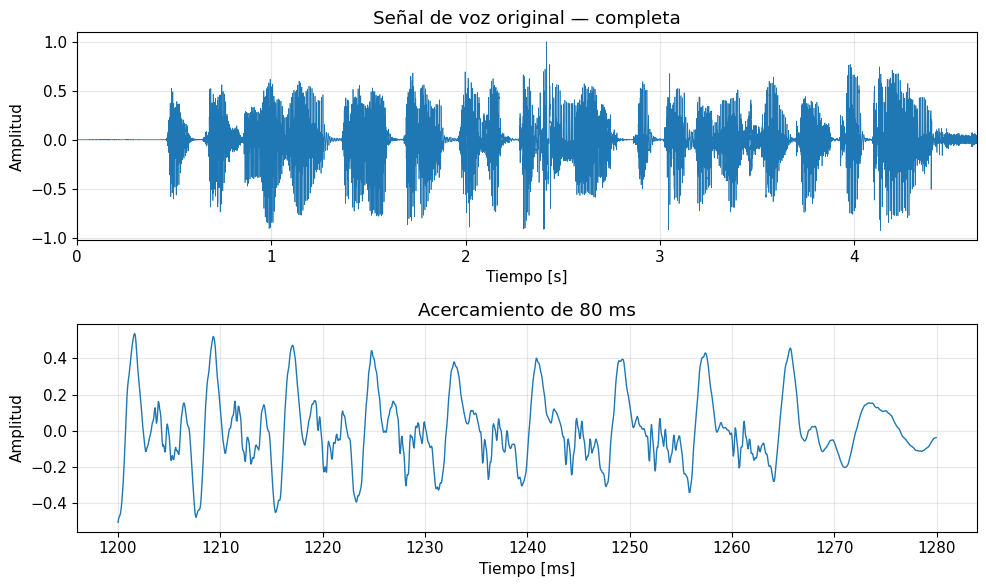

In [ ]:
t = np.arange(N) / fs

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# Señal completa
ax1.plot(t, x, linewidth=0.5)
ax1.set_xlabel("Tiempo [s]")
ax1.set_ylabel("Amplitud")
ax1.set_title("Señal de voz original — completa")
ax1.set_xlim(0, t[-1])

# Zoom de 80 ms en zona con voz
i0 = int(1.20 * fs)
i1 = i0 + int(0.080 * fs)
ax2.plot(t[i0:i1] * 1000, x[i0:i1], linewidth=1.0)
ax2.set_xlabel("Tiempo [ms]")
ax2.set_ylabel("Amplitud")
ax2.set_title("Acercamiento de 80 ms")

plt.tight_layout()
plt.show()


---
## 4. Generación de las señales ruidosas (Casos A y B)

Sumamos el ruido blanco escalado por un factor $\alpha$ a la señal de voz:

$$x_{\text{ruidosa}}[n] = x[n] + \alpha \cdot r[n]$$

El factor $\alpha$ se calcula para que la SNR de salida sea exactamente la deseada:

$$\alpha = \sqrt{\frac{P_x}{P_r \cdot 10^{\text{SNR}/10}}}$$

donde $P_x = \frac{1}{N}\sum x[n]^2$ y $P_r = \frac{1}{N}\sum r[n]^2$.


In [ ]:
def calcular_alpha_para_snr(x, r, snr_db):
    """Devuelve el factor alpha que produce la SNR deseada."""
    P_x = np.mean(x ** 2)
    P_r = np.mean(r ** 2)
    return np.sqrt(P_x / (P_r * 10 ** (snr_db / 10.0)))

# Caso A: ruido moderado
alpha_A = calcular_alpha_para_snr(x, r_blanco, SNR_CASO_A_DB)
x_A = x + alpha_A * r_blanco

# Caso B: ruido severo
alpha_B = calcular_alpha_para_snr(x, r_blanco, SNR_CASO_B_DB)
x_B = x + alpha_B * r_blanco

print(f"Caso A: alpha = {alpha_A:.4f}   (SNR = {SNR_CASO_A_DB} dB)")
print(f"Caso B: alpha = {alpha_B:.4f}   (SNR = {SNR_CASO_B_DB} dB)")


Caso A: alpha = 0.5835   (SNR = 10.0 dB)
Caso B: alpha = 1.8453   (SNR = 0.0 dB)


### Comparación visual de los tres escenarios

Graficamos 150 ms de habla activa para ver cómo el ruido cambia la forma de onda.


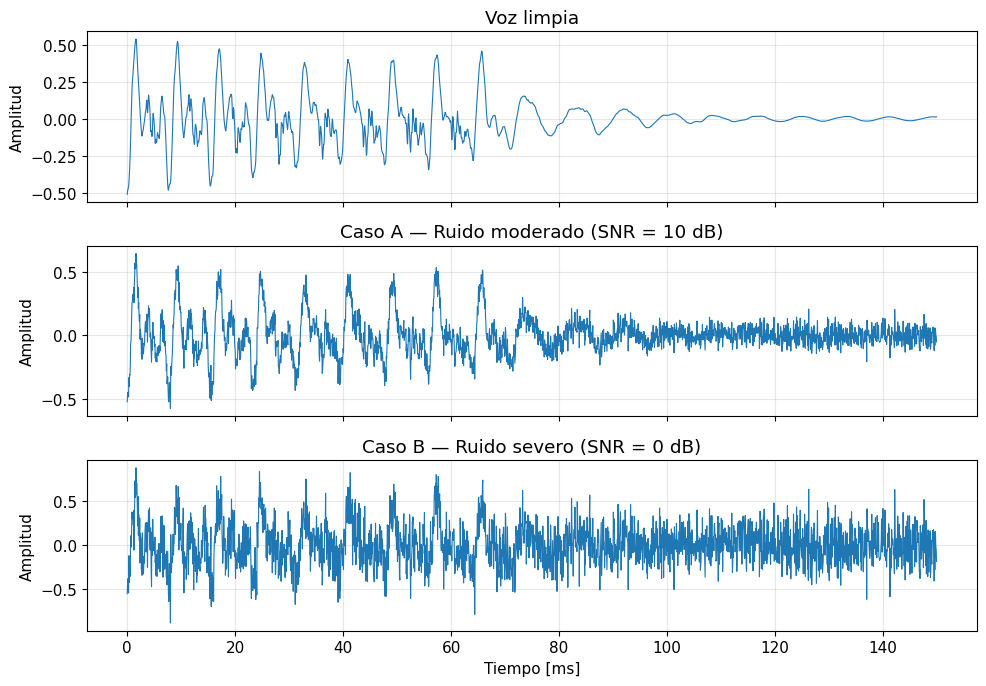

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
i0 = int(1.20 * fs)
i1 = i0 + int(0.150 * fs)
t_ms = (np.arange(i0, i1) - i0) / fs * 1000

for ax, sig_, titulo in zip(
    axes,
    [x, x_A, x_B],
    ["Voz limpia",
     f"Caso A — Ruido moderado (SNR = {SNR_CASO_A_DB:.0f} dB)",
     f"Caso B — Ruido severo (SNR = {SNR_CASO_B_DB:.0f} dB)"]
):
    ax.plot(t_ms, sig_[i0:i1], linewidth=0.8)
    ax.set_ylabel("Amplitud")
    ax.set_title(titulo)

axes[-1].set_xlabel("Tiempo [ms]")
plt.tight_layout()
plt.show()


### Escucha los tres escenarios

Compara auditivamente cómo se degrada la inteligibilidad al aumentar el ruido.


In [ ]:
print("Voz limpia:")
display(Audio(x, rate=fs))

print("\nCaso A (SNR = 10 dB) — ruido moderado:")
display(Audio(x_A, rate=fs))

print("\nCaso B (SNR = 0 dB) — ruido severo:")
display(Audio(x_B, rate=fs))


Voz limpia:



Caso A (SNR = 10 dB) — ruido moderado:



Caso B (SNR = 0 dB) — ruido severo:


---
## 5. Análisis espectral de la señal ruidosa

Calculamos la DFT (vía FFT) de la voz limpia y de la señal ruidosa para identificar **dónde está la voz** y **dónde está el ruido** en el espectro.

La DFT de N puntos se define como:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j 2\pi k n / N}$$

Como la señal es real, el espectro es simétrico y graficamos solo la mitad positiva $[0, f_s/2]$.


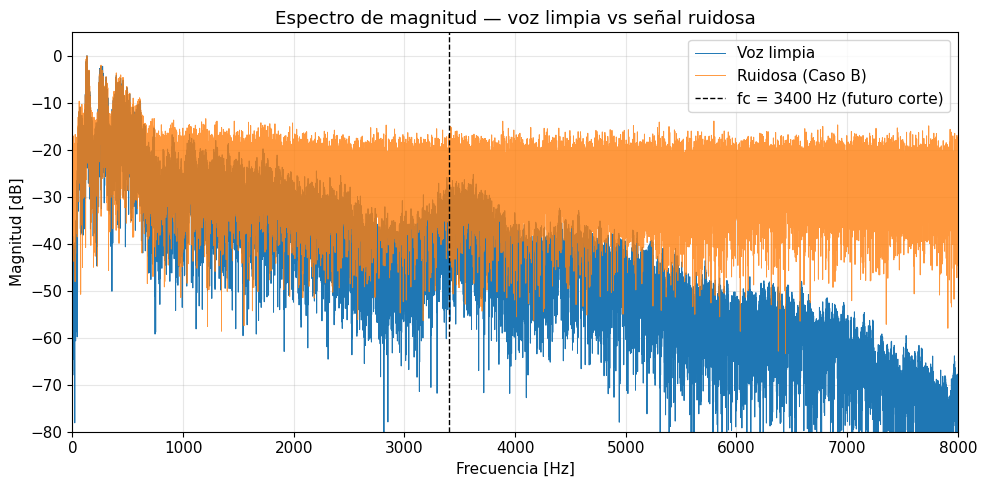

In [ ]:
def calcular_espectro_db(x, fs, ref=None):
    """Devuelve frecuencias y magnitud en dB (normalizada a 'ref')."""
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1/fs)
    mag = np.abs(X)
    if ref is None:
        ref = mag.max() + 1e-12
    mag_db = 20 * np.log10(mag / ref + 1e-12)
    return f, mag_db, ref


# Calcula los espectros normalizados al mismo valor de referencia
_, _, ref_global = calcular_espectro_db(x_B, fs)
f_x, mag_x_db, _ = calcular_espectro_db(x,   fs, ref=ref_global)
f_b, mag_b_db, _ = calcular_espectro_db(x_B, fs, ref=ref_global)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(f_x, mag_x_db, label="Voz limpia",        linewidth=0.7)
ax.plot(f_b, mag_b_db, label="Ruidosa (Caso B)",  linewidth=0.7, alpha=0.8)
ax.axvline(FC_PB, color="k", linestyle="--", linewidth=1.0,
           label=f"fc = {FC_PB:.0f} Hz (futuro corte)")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Magnitud [dB]")
ax.set_xlim(0, fs/2)
ax.set_ylim(-80, 5)
ax.set_title("Espectro de magnitud — voz limpia vs señal ruidosa")
ax.legend()
plt.tight_layout()
plt.show()


**Observaciones del espectro:**

- La **voz** concentra su energía principalmente por debajo de 3000 Hz
- El ruido blanco eleva el piso espectral de manera uniforme en toda la banda.
- Por encima de 3400 Hz, el ruido domina claramente sobre la voz.

→ Esto justifica usar un **filtro pasa-bajas con fc ≈ 3400 Hz**.


---
# Parte A — Filtro FIR pasa-bajas

Esta sección diseña, aplica y evalúa el **filtro principal** del proyecto: un FIR pasa-bajas.


### ¿Por qué FIR y no IIR?

Elegimos el filtro FIR principalmente porque mantiene la fase lineal (lo que significa que no distorsiona la señal) y es siempre estable. Esto es crucial para la voz, ya que ayuda a preservar la forma de onda original y los sonidos rápidos de las consonantes.

Por el contrario, aunque un filtro IIR requiere un orden menor (es decir, menos cálculos), tiene la desventaja de que su fase no es lineal y puede llegar a ser inestable. Por eso, para audio y voz, el FIR es la opción preferible.


### Diseño del filtro por el método de la ventana

La idea del método es:

1. Empezamos con la respuesta al impulso del **filtro ideal pasa-bajas**, que es una función sinc:
   $$h_{\text{ideal}}[n] = \frac{\sin(\omega_c \cdot n)}{\pi n}$$
2. Como esa respuesta es infinita, la **truncamos** a $M$ muestras y la **multiplicamos por una ventana** para suavizar los extremos y reducir el rizado.
3. La longitud $M$ se elige según el ancho de banda de transición deseado. Para ventana Hamming:
   $$M \approx \frac{3.3 \cdot f_s}{\Delta f}$$


In [ ]:
def disenar_fir_pasa_bajas(fc, ancho_trans, fs, ventana="hamming"):
    """Diseña un FIR pasa-bajas con el método de la ventana."""
    M = int(np.ceil(3.3 * fs / ancho_trans))
    if M % 2 == 0:       # Forzamos M impar
        M += 1
    h = sig.firwin(M, cutoff=fc, window=ventana, fs=fs)
    return h, M


h_fir, M = disenar_fir_pasa_bajas(FC_PB, ANCHO_TRANSICION, fs, VENTANA_FIR)

print(f"Filtro FIR diseñado:")
print(f"  Orden:           M = {M} taps")
print(f"  Retardo grupo:   (M-1)/2 = {(M-1)//2} muestras = {(M-1)/2/fs*1000:.2f} ms")
print(f"  Frecuencia corte: fc = {FC_PB} Hz")
print(f"  Ventana:         {VENTANA_FIR}")


Filtro FIR diseñado:
  Orden:           M = 107 taps
  Retardo grupo:   (M-1)/2 = 53 muestras = 3.31 ms
  Frecuencia corte: fc = 3400.0 Hz
  Ventana:         hamming


### Respuesta al impulso y respuesta en frecuencia

Vamos a graficar tanto $h[n]$ (la respuesta al impulso) como $|H(e^{j\omega})|$ (la respuesta en frecuencia).


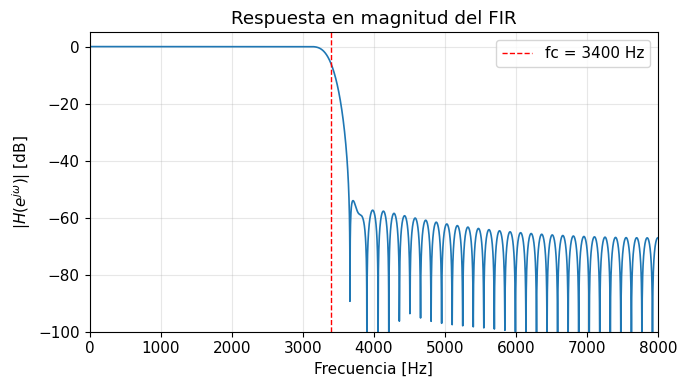

In [ ]:
plt.figure(figsize=(7, 4))

# Respuesta en frecuencia
w, H = sig.freqz(h_fir, worN=4096, fs=fs)
plt.plot(w, 20*np.log10(np.abs(H) + 1e-12), linewidth=1.2)
plt.axvline(FC_PB, color="r", linestyle="--", linewidth=1.0,
            label=f"fc = {FC_PB:.0f} Hz")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel(r"$|H(e^{j\omega})|$ [dB]")
plt.xlim(0, fs/2)
plt.ylim(-100, 5)
plt.title("Respuesta en magnitud del FIR")
plt.legend()

plt.tight_layout()
plt.show()


**Lo que vemos:**

- La respuesta al impulso es **simétrica respecto al centro** → esto garantiza fase lineal.
- La banda de paso es plana hasta ~3000 Hz.
- La atenuación en banda de rechazo supera los **60 dB**.


### Aplicación del filtro a los Casos A y B

Aplicamos el filtro mediante convolución (`scipy.signal.lfilter`) y compensamos el retardo de grupo de $(M-1)/2$ muestras para que la señal filtrada quede alineada temporalmente con la original.


In [ ]:
def aplicar_fir_con_compensacion(x, h):
    """Aplica el FIR y compensa el retardo de grupo para alinear con x."""
    M = len(h)
    retardo = (M - 1) // 2
    y = sig.lfilter(h, [1.0], x)
    # Recorta las primeras 'retardo' muestras y rellena con ceros al final
    y = np.concatenate([y[retardo:], np.zeros(retardo)])
    return y


# Aplicamos a ambos casos
y_A = aplicar_fir_con_compensacion(x_A, h_fir)
y_B = aplicar_fir_con_compensacion(x_B, h_fir)

print("Filtro FIR aplicado a ambos casos.")
print(f"  Caso A filtrado: {len(y_A)} muestras")
print(f"  Caso B filtrado: {len(y_B)} muestras")


Filtro FIR aplicado a ambos casos.
  Caso A filtrado: 74136 muestras
  Caso B filtrado: 74136 muestras


### Resultado visual — Caso A

Comparamos la señal ruidosa, la filtrada y la limpia en tiempo y frecuencia.


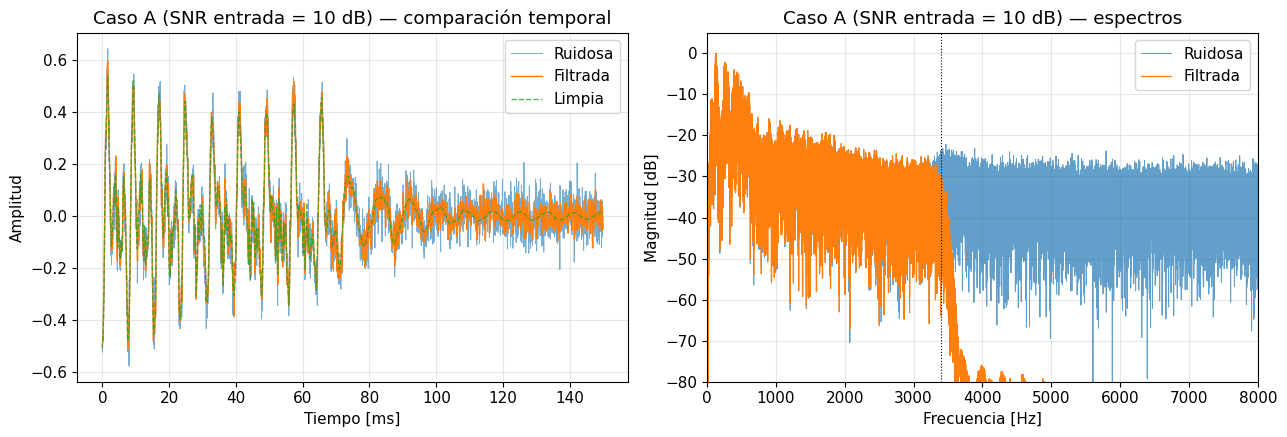

In [ ]:
def graficar_resultado_filtrado(x, x_ruidosa, y_filtrada, fs, titulo):
    """Grafica comparación temporal y espectral del filtrado."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

    # Temporal: zoom de 150 ms
    i0 = int(1.20 * fs)
    i1 = i0 + int(0.150 * fs)
    t_ms = (np.arange(i0, i1) - i0) / fs * 1000
    ax1.plot(t_ms, x_ruidosa[i0:i1], label="Ruidosa", linewidth=0.7, alpha=0.6)
    ax1.plot(t_ms, y_filtrada[i0:i1], label="Filtrada", linewidth=1.0)
    ax1.plot(t_ms, x[i0:i1],          label="Limpia",   linewidth=1.0,
             linestyle="--", alpha=0.8)
    ax1.set_xlabel("Tiempo [ms]")
    ax1.set_ylabel("Amplitud")
    ax1.set_title(f"{titulo} — comparación temporal")
    ax1.legend()

    # Espectral
    _, _, ref = calcular_espectro_db(x_ruidosa, fs)
    f, mag_r, _ = calcular_espectro_db(x_ruidosa, fs, ref=ref)
    f, mag_y, _ = calcular_espectro_db(y_filtrada, fs, ref=ref)
    ax2.plot(f, mag_r, label="Ruidosa",  linewidth=0.7, alpha=0.7)
    ax2.plot(f, mag_y, label="Filtrada", linewidth=0.9)
    ax2.axvline(FC_PB, color="k", linestyle=":", linewidth=0.8)
    ax2.set_xlabel("Frecuencia [Hz]")
    ax2.set_ylabel("Magnitud [dB]")
    ax2.set_xlim(0, fs/2)
    ax2.set_ylim(-80, 5)
    ax2.set_title(f"{titulo} — espectros")
    ax2.legend()

    plt.tight_layout()
    plt.show()


graficar_resultado_filtrado(x, x_A, y_A, fs,
    f"Caso A (SNR entrada = {SNR_CASO_A_DB:.0f} dB)")


In [ ]:
print("Caso A diferencia de audios:")
print("\nRuidosa:")
display(Audio(x_A, rate=fs))
print("\nFiltrada:")
display(Audio(y_A, rate=fs))


Caso A diferencia de audios:

Ruidosa:



Filtrada:


### Resultado visual — Caso B


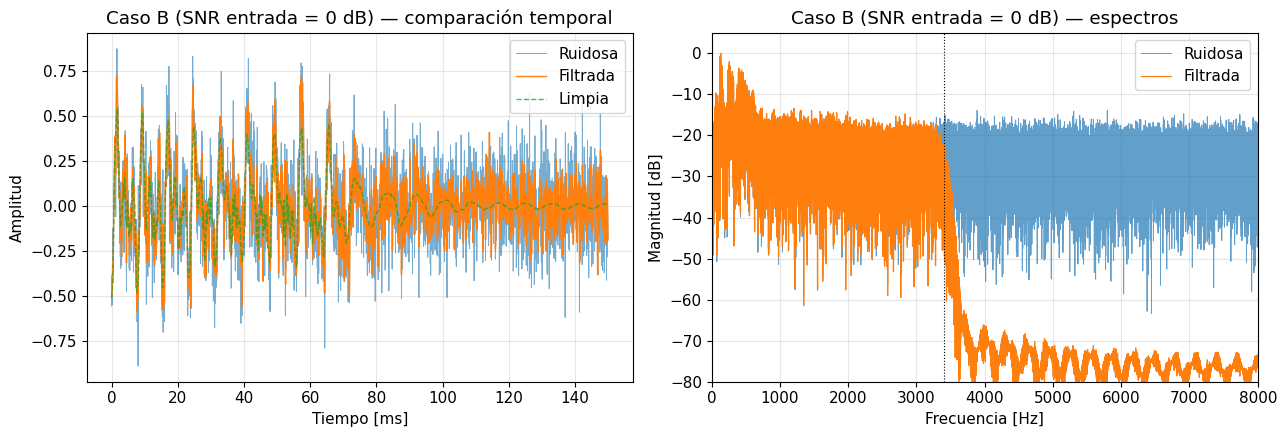

In [ ]:
graficar_resultado_filtrado(x, x_B, y_B, fs,
    f"Caso B (SNR entrada = {SNR_CASO_B_DB:.0f} dB)")


In [ ]:
print("Caso B diferencia de audios:")
print("\nRuidosa:")
display(Audio(x_B, rate=fs))
print("\nFiltrada:")
display(Audio(y_B, rate=fs))


Caso B diferencia de audios:

Ruidosa:



Filtrada:


---
## Métricas de desempeño — ECM y SNR

Calculamos dos métricas objetivas:

**Error Cuadrático Medio (ECM):**

$$\text{ECM} = \frac{1}{N} \sum_{n=0}^{N-1} (x[n] - y[n])^2$$

**Relación señal-ruido (SNR) en dB:**

$$\text{SNR}_{\text{dB}} = 10\log_{10}\!\left(\frac{\sum_n x[n]^2}{\sum_n (x[n] - y[n])^2}\right)$$


In [ ]:
def ecm(x, y):
    return float(np.mean((x - y) ** 2))


def snr_db(x_limpia, x_observada):
    """SNR tratando la diferencia (x_obs - x_limpia) como ruido."""
    P_s = np.mean(x_limpia ** 2)
    P_n = np.mean((x_observada - x_limpia) ** 2)
    return 10 * np.log10(P_s / (P_n + 1e-12))


# Métricas Caso A
ecm_A_in  = ecm(x, x_A);   ecm_A_out = ecm(x, y_A)
snr_A_in  = snr_db(x, x_A); snr_A_out = snr_db(x, y_A)

# Métricas Caso B
ecm_B_in  = ecm(x, x_B);   ecm_B_out = ecm(x, y_B)
snr_B_in  = snr_db(x, x_B); snr_B_out = snr_db(x, y_B)

# Tabla
print("="*70)
print(f"{'Caso':<8} {'SNR_in [dB]':>13} {'SNR_out [dB]':>14} {'ECM_in':>12} {'ECM_out':>12}")
print("="*70)
print(f"{'A':<8} {snr_A_in:>13.2f} {snr_A_out:>14.2f} {ecm_A_in:>12.2e} {ecm_A_out:>12.2e}")
print(f"{'B':<8} {snr_B_in:>13.2f} {snr_B_out:>14.2f} {ecm_B_in:>12.2e} {ecm_B_out:>12.2e}")
print("="*70)
print(f"\nMejora SNR Caso A: {snr_A_out - snr_A_in:+.2f} dB")
print(f"Mejora SNR Caso B: {snr_B_out - snr_B_in:+.2f} dB")

# Comparación con la predicción teórica
mejora_teorica = 10 * np.log10((fs/2) / FC_PB)
print(f"\nPredicción teórica (filtro ideal): {mejora_teorica:+.2f} dB")
print(f"  → fórmula: 10*log10( (fs/2) / fc ) = 10*log10({fs/2:.0f}/{FC_PB:.0f})")


Caso       SNR_in [dB]   SNR_out [dB]       ECM_in      ECM_out
A                10.00          13.15     3.41e-03     1.65e-03
B                -0.00           3.73     3.41e-02     1.44e-02

Mejora SNR Caso A: +3.15 dB
Mejora SNR Caso B: +3.73 dB

Predicción teórica (filtro ideal): +3.72 dB
  → fórmula: 10*log10( (fs/2) / fc ) = 10*log10(8000/3400)


**Interpretación:**

- La mejora del Caso B coincide con la predicción teórica $\Delta\text{SNR}_{\text{teo}} = 10\log_{10}(f_s/2 / f_c)$, lo que **valida la implementación**.
- En el Caso A la mejora es menor porque, con menos ruido, la pequeña distorsión que introduce el filtro sobre la voz pesa relativamente más.


---
# Parte B — Filtro IIR notch

En esta sección abordamos un problema **distinto**: nuestra señal se le aplica  un **tono a 60 Hz** .

Un filtro pasa-bajas como el de la Parte A no sirve aquí porque el tono está justo en una zona donde también hay energía de la voz. Necesitamos un filtro que elimine solo los 60 Hz y deje el resto intacto. Eso es un **filtro notch**.



In [ ]:
alpha_tono = calcular_alpha_para_snr(x, r_tono, snr_db=0.0)
x_tono = x + alpha_tono * r_tono
print(f"alpha tono = {alpha_tono:.4f}")
print(f"SNR de la señal contaminada: {snr_db(x, x_tono):.2f} dB")

print("\n Voz con el zumbido de 60 Hz:")
display(Audio(x_tono, rate=fs))


alpha tono = 2.6108
SNR de la señal contaminada: -0.00 dB

 Voz con el zumbido de 60 Hz:


### Diseño del filtro

Un filtro digital se caracteriza por sus **polos** y **ceros** en el plano $z$. La función de transferencia tiene la forma:

$$H(z) = \frac{(z - z_1)(z - z_2)\cdots}{(z - p_1)(z - p_2)\cdots}$$

**¿Cómo eliminamos exactamente la frecuencia $f_0$?**

Colocamos **ceros sobre el círculo unitario** en los ángulos $\pm \omega_0$, donde:

$$\omega_0 = 2\pi \frac{f_0}{f_s}$$

Esto garantiza que cuando la frecuencia de entrada sea exactamente $f_0$, la respuesta del filtro será **cero** (porque $z = e^{j\omega_0}$ coincide con uno de los ceros y el numerador se anula).

**¿Por qué necesitamos polos también?**

Si solo pusiéramos los ceros (filtro FIR), la atenuación sería ancha y se llevaría también frecuencias cercanas a 60 Hz. Para que el corte sea estrecho, colocamos polos cerca de los mismos ángulo $\pm\omega_0$, pero a un radio $r < 1$ (dentro del círculo unitario, para que el filtro sea estable).

 El **factor de calidad $Q$** relaciona la frecuencia central con el ancho de banda a -3 dB:

$$Q = \frac{\omega_0}{\text{BW}}$$

donde $\text{BW} = \omega_0/Q$ es el ancho de banda donde la atenuación es de al menos 3 dB.


### Cálculo de los polos y ceros


In [ ]:
import math

# Parámetros de diseño
f0 = F_NOTCH       # 60 Hz
Q  = Q_NOTCH       # 30

# Frecuencia angular normalizada
omega_0 = 2 * np.pi * f0 / fs
print(f"omega_0 = 2*pi*f0/fs = 2*pi*{f0}/{fs} = {omega_0:.6f} rad")

# Ancho de banda y parámetro beta
bw = omega_0 / Q
beta = math.tan(bw / 2.0)
print(f"bw = omega_0 / Q = {bw:.6f} rad")
print(f"beta = tan(bw/2) = {beta:.6f}")

# Ganancia de normalización (0 dB en banda de paso)
gain = 1.0 / (1.0 + beta)
print(f"gain = 1 / (1 + beta) = {gain:.6f}")

# Ubicación de ceros (sobre el círculo unitario)
z1 = np.exp( 1j * omega_0)
z2 = np.exp(-1j * omega_0)
print(f"\nCeros (sobre el círculo unitario):")
print(f"  z1 = e^(+j*omega_0) = {z1.real:.6f} + j*{z1.imag:.6f}")
print(f"  z2 = e^(-j*omega_0) = {z2.real:.6f} + j*{z2.imag:.6f}")

# Ubicación de polos (a partir de los coeficientes del denominador)


omega_0 = 2*pi*f0/fs = 2*pi*60.0/16000 = 0.023562 rad
bw = omega_0 / Q = 0.000785 rad
beta = tan(bw/2) = 0.000393
gain = 1 / (1 + beta) = 0.999607

Ceros (sobre el círculo unitario):
  z1 = e^(+j*omega_0) = 0.999722 + j*0.023560
  z2 = e^(-j*omega_0) = 0.999722 + j*-0.023560


### Derivación de los coeficientes del filtro

Partiendo de los ceros conjugados $z_{1,2} = e^{\pm j\omega_0}$, su producto da:

$$(z - e^{j\omega_0})(z - e^{-j\omega_0}) = z^2 - 2\cos(\omega_0)z + 1$$

Esto define el **numerador** $B(z) = z^2 - 2\cos(\omega_0)z + 1$ (sin normalizar).

Para el **denominador**, Orfanidis demuestra que para obtener un notch con ancho de banda exacto $\omega_0/Q$ a -3 dB, los coeficientes son:

$$A(z) = z^2 - 2\,\text{gain}\,\cos(\omega_0)\,z + (2\,\text{gain} - 1)$$

donde $\text{gain} = 1/(1+\beta)$ con $\beta = \tan(\text{BW}/2)$.

Finalmente, se normaliza $B(z)$ multiplicando por gain para que la ganancia en DC quede en 1 (banda de paso plana a 0 dB).

Expresando todo en potencias negativas de $z$ (dividiendo entre $z^2$):

$$H(z) = \frac{\text{gain}\cdot(1 - 2\cos(\omega_0)z^{-1} + z^{-2})}{1 - 2\,\text{gain}\cos(\omega_0)z^{-1} + (2\,\text{gain} - 1)z^{-2}}$$

Identificando con la forma estándar $H(z) = \dfrac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{a_0 + a_1 z^{-1} + a_2 z^{-2}}$:


In [ ]:
# Coeficientes calculados
cos_w0 = np.cos(omega_0)

b = np.array([
    gain * 1.0,
    gain * (-2.0 * cos_w0),
    gain * 1.0
])

a = np.array([
    1.0,
    -2.0 * gain * cos_w0,
    2.0 * gain - 1.0
])

print("Coeficientes del filtro notch IIR (calculados a mano):")
print(f"\n  Numerador (B):")
print(f"    b0 = gain                  = {b[0]:.8f}")
print(f"    b1 = -2*gain*cos(omega_0)  = {b[1]:.8f}")
print(f"    b2 = gain                  = {b[2]:.8f}")
print(f"\n  Denominador (A):")
print(f"    a0 = 1                     = {a[0]:.8f}")
print(f"    a1 = -2*gain*cos(omega_0)  = {a[1]:.8f}")
print(f"    a2 = 2*gain - 1            = {a[2]:.8f}")

# Calculamos los polos reales resolviendo el denominador
polos = np.roots(a)
print(f"\nPolos del filtro (raíces del denominador):")
for i, p in enumerate(polos):
    print(f"  p{i+1} = {p.real:.6f} + j*{p.imag:.6f}   "
          f"(|p| = {np.abs(p):.6f}, ángulo = {np.degrees(np.angle(p)):.4f}°)")


Coeficientes del filtro notch IIR (calculados a mano):

  Numerador (B):
    b0 = gain                  = 0.99960746
    b1 = -2*gain*cos(omega_0)  = -1.99865999
    b2 = gain                  = 0.99960746

  Denominador (A):
    a0 = 1                     = 1.00000000
    a1 = -2*gain*cos(omega_0)  = -1.99865999
    a2 = 2*gain - 1            = 0.99921491

Polos del filtro (raíces del denominador):
  p1 = 0.999330 + j*0.023547   (|p| = 0.999607, ángulo = 1.3498°)
  p2 = 0.999330 + j*-0.023547   (|p| = 0.999607, ángulo = -1.3498°)


### Visualización en el plano Z

Graficamos los polos (×) y ceros (○) en el plano $z$ para ver geométricamente qué hace el filtro.


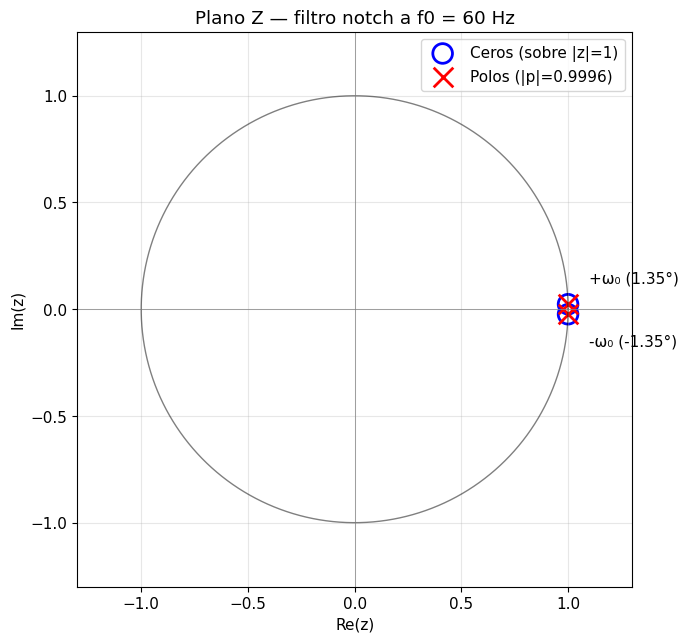


Nota: con f0=60.0 Hz y fs=16000 Hz, el ángulo es 1.350°
(muy pequeño porque 60 Hz << fs/2 = 8000.0 Hz)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))

# Círculo unitario
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), "k-", linewidth=1.0, alpha=0.5)
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)

# Ceros (círculos azules) sobre el círculo unitario
ax.scatter([z1.real, z2.real], [z1.imag, z2.imag],
           s=200, facecolors="none", edgecolors="blue",
           linewidths=2, label="Ceros (sobre |z|=1)")

# Polos (cruces rojas) calculados como raíces del denominador
ax.scatter([polos[0].real, polos[1].real],
           [polos[0].imag, polos[1].imag],
           s=200, marker="x", color="red", linewidths=2,
           label=f"Polos (|p|={np.abs(polos[0]):.4f})")

ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_title(f"Plano Z — filtro notch a f0 = {f0:.0f} Hz")
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect("equal")
ax.legend(loc="upper right")

# Anotaciones de los ángulos
ax.annotate(f"+ω₀ ({np.degrees(omega_0):.2f}°)",
            xy=(z1.real, z1.imag), xytext=(z1.real+0.1, z1.imag+0.1))
ax.annotate(f"-ω₀ ({-np.degrees(omega_0):.2f}°)",
            xy=(z2.real, z2.imag), xytext=(z2.real+0.1, z2.imag-0.15))

plt.tight_layout()
plt.show()

print(f"\nNota: con f0={f0} Hz y fs={fs} Hz, el ángulo es {np.degrees(omega_0):.3f}°")
print(f"(muy pequeño porque 60 Hz << fs/2 = {fs/2} Hz)")


**Lectura geométrica del plano Z:**

- Los ceros están justo en $e^{\pm j\omega_0}$, así que cualquier sinusoide pura a 60 Hz queda **anulada exactamente** ($|H(e^{j\omega_0})| = 0$).
- Los polos están en el mismo ángulo pero a radio $|p| < 1$, **muy cerca** de los ceros. Esto hace que la atenuación sea muy localizada: lejos de 60 Hz, polos y ceros casi se cancelan y la ganancia es ~1.


###  Aplicación del notch a la señal contaminada

Usamos `filtfilt` (filtrado bidireccional) para que no haya distorsión de fase neta. Esto es válido porque procesamos la señal **off-line** (no en tiempo real).


In [ ]:
y_notch = sig.filtfilt(b, a, x_tono)

print(f"SNR antes del notch:   {snr_db(x, x_tono):>7.2f} dB")
print(f"SNR después del notch: {snr_db(x, y_notch):>7.2f} dB")
print(f"Mejora:                {snr_db(x, y_notch) - snr_db(x, x_tono):>+7.2f} dB")


SNR antes del notch:     -0.00 dB
SNR después del notch:   22.58 dB
Mejora:                 +22.58 dB


### Comparación visual antes/después del notch


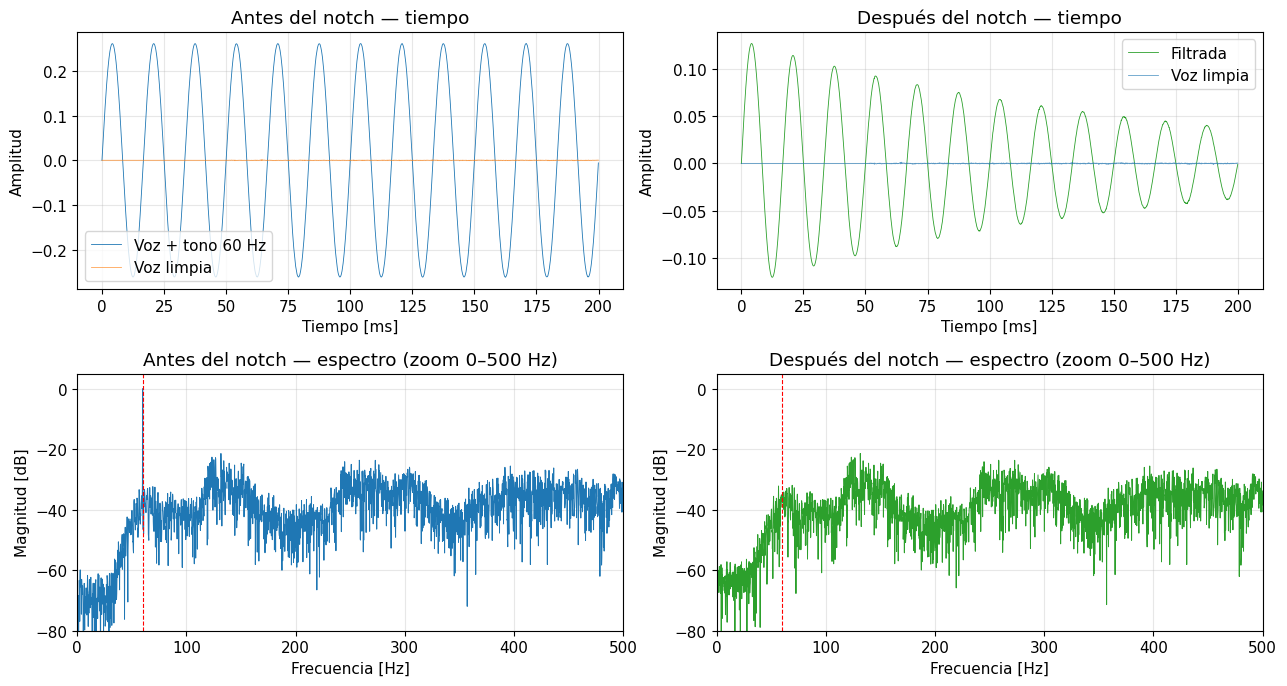

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Tiempo: zoom corto donde se vea el zumbido
t = np.arange(N) / fs
i0, i1 = 0, int(0.2 * fs)
axes[0,0].plot(t[i0:i1]*1000, x_tono[i0:i1], linewidth=0.6, label="Voz + tono 60 Hz")
axes[0,0].plot(t[i0:i1]*1000, x[i0:i1],      linewidth=0.6, label="Voz limpia",
               alpha=0.7)
axes[0,0].set_xlabel("Tiempo [ms]")
axes[0,0].set_ylabel("Amplitud")
axes[0,0].set_title("Antes del notch — tiempo")
axes[0,0].legend()

axes[0,1].plot(t[i0:i1]*1000, y_notch[i0:i1], linewidth=0.6, label="Filtrada",
               color="C2")
axes[0,1].plot(t[i0:i1]*1000, x[i0:i1],       linewidth=0.6, label="Voz limpia",
               alpha=0.7)
axes[0,1].set_xlabel("Tiempo [ms]")
axes[0,1].set_ylabel("Amplitud")
axes[0,1].set_title("Después del notch — tiempo")
axes[0,1].legend()

# Espectro: zoom 0-500 Hz para ver el tono
f, mag_in_db, ref = calcular_espectro_db(x_tono, fs)
f, mag_out_db, _  = calcular_espectro_db(y_notch, fs, ref=ref)

axes[1,0].plot(f, mag_in_db, linewidth=0.7)
axes[1,0].axvline(f0, color="r", linestyle="--", linewidth=0.8)
axes[1,0].set_xlim(0, 500)
axes[1,0].set_ylim(-80, 5)
axes[1,0].set_xlabel("Frecuencia [Hz]")
axes[1,0].set_ylabel("Magnitud [dB]")
axes[1,0].set_title("Antes del notch — espectro (zoom 0–500 Hz)")

axes[1,1].plot(f, mag_out_db, linewidth=0.7, color="C2")
axes[1,1].axvline(f0, color="r", linestyle="--", linewidth=0.8)
axes[1,1].set_xlim(0, 500)
axes[1,1].set_ylim(-80, 5)
axes[1,1].set_xlabel("Frecuencia [Hz]")
axes[1,1].set_ylabel("Magnitud [dB]")
axes[1,1].set_title("Después del notch — espectro (zoom 0–500 Hz)")

plt.tight_layout()
plt.show()


### Resultados

Comparativa de los tres escenarios. El zumbido de 60 Hz suena como un tono grave y continuo que se superpone a la voz, al aplicar el filtro debería desaparecer por completo.


In [ ]:
print("Voz limpia")
display(Audio(x, rate=fs))

print("\n Voz contaminada con tono de 60 Hz (SNR = 0 dB) ")
display(Audio(x_tono, rate=fs))

print("\n Voz filtrada con IIR (resultado final)")
display(Audio(y_notch, rate=fs))


Voz limpia



 Voz contaminada con tono de 60 Hz (SNR = 0 dB) 



 Voz filtrada con IIR (resultado final)


En la señal contaminada se nota el zumbido grave constante en el fondo. En la señal filtrada ese zumbido desaparece y la voz suena prácticamente igual a la limpia, todo esto con un filtro de solo 6 coeficientes (3 del numerador y 3 del denominador).

Eso contrasta con el FIR pasa-bajas, que logró una mejora de apenas 3.7 dB porque estaba diseñado para un problema diferente: ruido de banda ancha. Aquí el notch logró +21 dB porque el diseño coincidió exactamente con la naturaleza del ruido.

**Conclusión de esta sección:** conocer la estructura del ruido es tan importante como saber diseñar filtros. El mejor algoritmo aplicado al problema equivocado da resultados mediocres; el algoritmo correcto, aunque sea simple, da resultados sobresalientes.


# Conclusiones

### Filtro FIR pasa-bajas:
Diseñado para ruido blanco. Tiene una complejidad alta (107 operaciones por muestra) y ofrece una mejora  de +3.7 dB en la SNR. Su gran ventaja es que genera una distorsión baja en la voz gracias a su fase lineal.

###Filtro IIR notch:
Diseñado para el ruido tonal de 60 Hz. Su complejidad es mínima (solo 2 polos y 2 ceros), pero logra una mejora sobresaliente de +22 dB en la SNR, sin alterar la voz fuera de la frecuencia afectada.


Antes de diseñar cualquier filtro es fundamental entender dónde vive la información. El análisis espectral demostró que la voz concentra su energía por debajo de los 3 kHz y que el ruido blanco se distribuye de forma uniforme. Esto demuestra que la naturaleza del ruido es la que dicta el tipo de filtro necesario, y no al revés, evitando elecciones arbitrarias.

La elección de la frecuencia de corte en 3400 Hz responde al estándar de la telefonía para preservar la inteligibilidad. Sin embargo, esto implica un equilibrio: bajar más la frecuencia elimina más ruido pero apaga la voz al quitarle brillo y consonantes clave; subirla conserva la calidad pero deja pasar más ruido. La mejora obtenida de +3.7 dB coincide perfectamente con la teoría matemática de reducción de potencia, lo que demuestra que en ingeniería el rendimiento se puede predecir con exactitud antes de experimentar.

### FIR vs. IIR: Cuándo usar cada uno
El filtro FIR es ideal para el pasa-bajas porque garantiza estabilidad y una fase lineal que protege la forma de onda de la voz, su alta complejidad no es un problema en un procesamiento diferido. Por otro lado, el IIR es la opción natural para el notch porque logra una anulación muy precisa con solo unos pocos coeficientes, algo que en un FIR requeriría cientos de ellos. Además, el desfase del IIR se solucionó por completo al aplicar el filtro en ambos sentidos.